/home/hy381/project/prelim/Label-free-CBM/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


saved_activations/cifar100_val_clip_RN50.pt


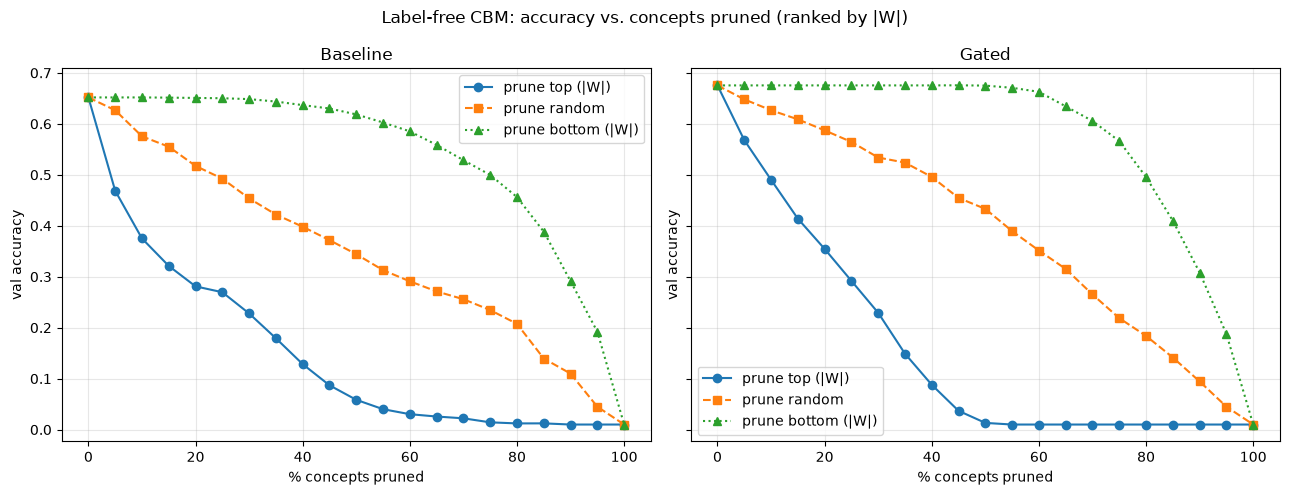

In [ ]:
import sys
sys.path.insert(0, '/home/hy381/project/prelim/Label-free-CBM')
from cbm import load_cbm
import utils, data_utils
import torch
import numpy as np
import matplotlib.pyplot as plt

DEVICE = 'cuda'
GATED_DIR = 'saved_models/cub_cbm_2026_08_06_08_10'
BASELINE_DIR    = 'saved_models/'
ACTIVATION_DIR = 'saved_activations'
DATASET  = 'cifar100'
BACKBONE = 'clip_RN50'
CLIP_NAME = 'RN50'
FEATURE_LAYER = 'layer4'
CONCEPT_SET = 'data/concept_sets/cifar100_filtered.txt'

# Load both models
baseline_cbm = load_cbm(BASELINE_DIR, DEVICE)
gated_cbm    = load_cbm(GATED_DIR,    DEVICE)

# Load pre-saved val backbone features (position 0 = target/backbone features)
val_feat_path, _, _ = utils.get_save_names(
    CLIP_NAME, BACKBONE, FEATURE_LAYER, f'{DATASET}_val', CONCEPT_SET, 'avg', ACTIVATION_DIR)
print(val_feat_path)
val_features = torch.load(val_feat_path, map_location=DEVICE).float()
val_targets  = torch.LongTensor(data_utils.get_targets_only(f'{DATASET}_val'))

# Compute proj_c per model — baseline has 826 concepts, gated has 827
def get_proj_c(cbm, features, device):
    with torch.no_grad():
        proj_c = cbm.proj_layer(features)
        proj_c = (proj_c - cbm.proj_mean.to(device)) / cbm.proj_std.to(device)
    return proj_c

proj_c_baseline = get_proj_c(baseline_cbm, val_features, DEVICE)
proj_c_gated    = get_proj_c(gated_cbm,    val_features, DEVICE)

# Per-model concept orderings ranked by that model's own |W|
def concept_orders(final_weight, n_concepts, seed=42):
    importance = final_weight.abs().mean(dim=0)
    np.random.seed(seed)
    return (
        importance.argsort(descending=True).tolist(),
        importance.argsort(descending=False).tolist(),
        np.random.permutation(n_concepts).tolist(),
    )

top_b, bot_b, rand_b = concept_orders(baseline_cbm.final.weight.data.cpu(), proj_c_baseline.shape[1])
top_g, bot_g, rand_g = concept_orders(gated_cbm.final.weight.data.cpu(),    proj_c_gated.shape[1])

def accuracy_after_pruning(proj_c, pruned_ids, final_layer, device):
    c = proj_c.clone()
    if pruned_ids:
        c[:, pruned_ids] = 0.0
    with torch.no_grad():
        logits = final_layer(c.to(device)).cpu()
    return (logits.argmax(dim=1) == val_targets).float().mean().item()

percentages = list(range(0, 101, 5))
results = {label: [] for label in [
    "baseline_top", "baseline_random", "baseline_bottom",
    "gated_top",    "gated_random",    "gated_bottom",
]}

for pct in percentages:
    for name, cbm, proj_c, top, bot, rand in [
        ("baseline", baseline_cbm, proj_c_baseline, top_b, bot_b, rand_b),
        ("gated",    gated_cbm,    proj_c_gated,    top_g, bot_g, rand_g),
    ]:
        k = int(pct / 100 * proj_c.shape[1])
        results[f"{name}_top"].append(
            accuracy_after_pruning(proj_c, top[:k], cbm.final, DEVICE))
        results[f"{name}_bottom"].append(
            accuracy_after_pruning(proj_c, bot[:k], cbm.final, DEVICE))
        results[f"{name}_random"].append(
            accuracy_after_pruning(proj_c, rand[:k], cbm.final, DEVICE))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
styles = {
    "top":    dict(marker="o", linestyle="-",  label="prune top (|W|)"),
    "random": dict(marker="s", linestyle="--", label="prune random"),
    "bottom": dict(marker="^", linestyle=":",  label="prune bottom (|W|)"),
}
for ax, name, title in zip(axes, ["baseline", "gated"], ["Baseline", "Gated"]):
    for condition, style in styles.items():
        ax.plot(percentages, results[f"{name}_{condition}"], **style)
    ax.set_xlabel("% concepts pruned")
    ax.set_ylabel("val accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Label-free CBM: accuracy vs. concepts pruned (ranked by |W|)")
plt.tight_layout()
plt.show()

Gated model — active concepts (gate > 0.5): 366 / 892


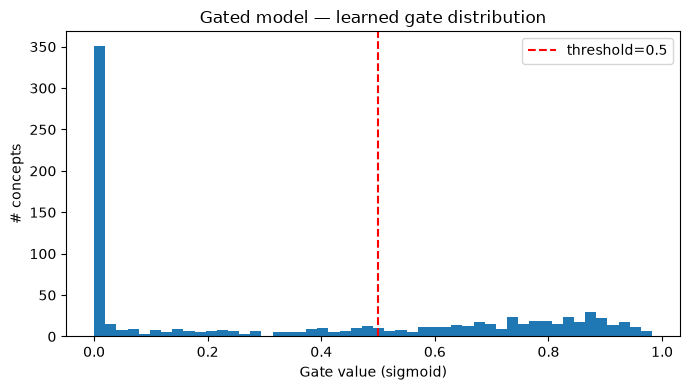

In [2]:
import os

# How many concepts does the gated model actively use?
# sigmoid(gate_logit) > 0.5 means gate_logit > 0, i.e. concept is "on".
gate_logits = torch.load(os.path.join(GATED_DIR, 'gate_logits.pt'), map_location='cpu')
gates = torch.sigmoid(gate_logits).detach()  # (n_concepts,)
n_active = (gates > 0.5).sum().item()
n_total  = gate_logits.shape[0]

print(f"Gated model — active concepts (gate > 0.5): {n_active} / {n_total}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gates.numpy(), bins=50, edgecolor='none')
ax.axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
ax.set_xlabel("Gate value (sigmoid)")
ax.set_ylabel("# concepts")
ax.set_title("Gated model — learned gate distribution")
ax.legend()
plt.tight_layout()
plt.show()